# 02 — Feature Engineering Diagnostics

Per v2 scheme §3.2: PACF + CCF lag selection on Morocco-only, winter-targeted data.

**Methodology (run per-fold in the modeling pipeline; here on the full record for sanity-checking)**:
- **Spatial aggregation**: shapefile-masked to Morocco (`shapefiles/MAR_adm0.shp`), then spatial mean → one 1-D series per variable ("approach A")
- **PACF** on the variable's own series, lags 1..12
- **CCF** between predictor lag k and SPEI3 at time t, restricted to target months ∈ [Nov, Feb] (`winter_only_ccf=True`)
- **Selected lags** = union of PACF-passing lags ∪ CCF-passing lags (threshold |·| > 0.20)
- **Fast-response variables** (Tmin, Tmax, Solar, Wind) tested at lag 1 only
- For comparison, the alternative "approach B" (per-cell PACF/CCF, then mean across cells) is run alongside

**Important**: spatial averaging is for *lag selection only*. The CV/modeling pipeline (Phases 3+) treats every (cell, time) sample as a separate observation — no spatial averaging at training time.

Figures saved to `results/figures/02_features/`.

In [8]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context='notebook', style='whitegrid')

from droughtmodel import data as ddata
from droughtmodel import features as dfeat
from droughtmodel.utils import save_figure

FIG_SUBDIR = '02_features'

data_config = ddata.load_config(ROOT / 'configs' / 'data.yaml')
feat_config = dfeat.load_features_config(ROOT / 'configs' / 'features.yaml')
datasets = ddata.load_all(data_config)

# Build the Morocco mask once
template = dfeat.gather_predictor('spei3', datasets)
morocco_mask = dfeat.load_region_mask(feat_config['region_mask']['path'], template, name='morocco')
print(f"Morocco mask: {int(morocco_mask.sum())} of {morocco_mask.size} cells inside ({100*float(morocco_mask.mean()):.1f}%)")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/opt/anaconda3/envs/droughtforecast/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Morocco mask: 164 of 4096 cells inside (4.0%)


## Morocco mask visualization

Which grid cells are inside the shapefile boundary.

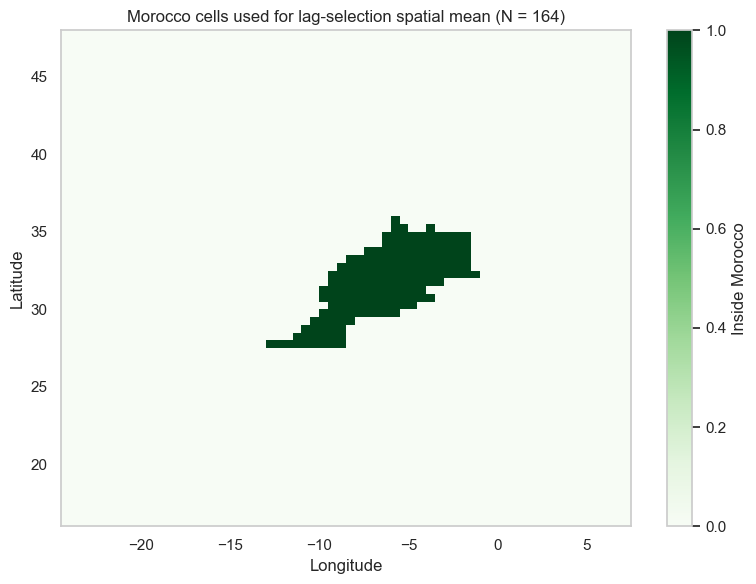

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
morocco_mask.astype(int).plot(ax=ax, cmap='Greens', cbar_kwargs={'label': 'Inside Morocco'})
ax.set_title(f'Morocco cells used for lag-selection spatial mean (N = {int(morocco_mask.sum())})')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
save_figure(fig, 'morocco_mask', subdir=FIG_SUBDIR)
plt.show()

## PACF — long-memory variables (Morocco spatial mean)

Bars above the dashed threshold (|PACF| > 0.20) survive PACF selection.

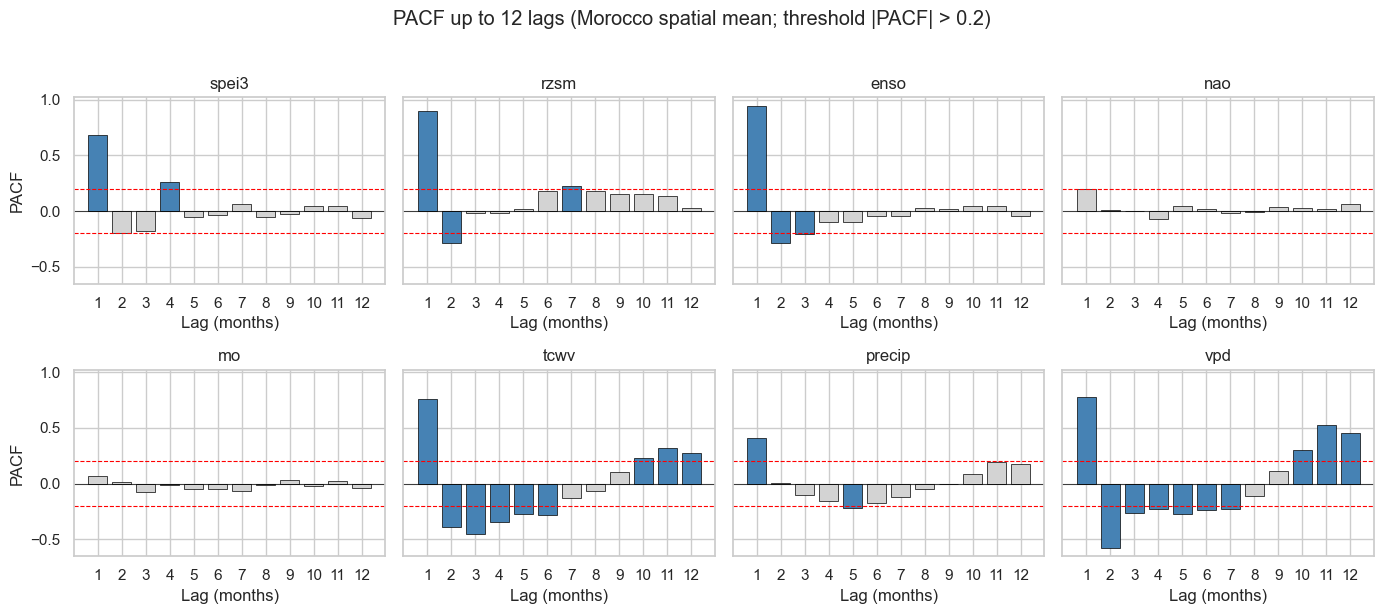

In [17]:
long_vars = feat_config['long_memory_vars']
n_lags = feat_config['pacf']['n_lags']
pacf_threshold = feat_config['pacf']['threshold']

n = len(long_vars)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3 * nrows), sharey=True)
axes = axes.flatten()

for i, var in enumerate(long_vars):
    da = dfeat.gather_predictor(var, datasets)
    series = dfeat.spatial_mean(da, mask=morocco_mask).values
    vals = dfeat.compute_pacf(series, n_lags=n_lags)
    lags = np.arange(1, n_lags + 1)
    colors = ['steelblue' if abs(v) > pacf_threshold else 'lightgray' for v in vals]
    axes[i].bar(lags, vals, color=colors, edgecolor='black', linewidth=0.5)
    axes[i].axhline(pacf_threshold, color='red', linestyle='--', linewidth=0.8)
    axes[i].axhline(-pacf_threshold, color='red', linestyle='--', linewidth=0.8)
    axes[i].axhline(0, color='black', linewidth=0.5)
    axes[i].set_title(var)
    axes[i].set_xlabel('Lag (months)')
    axes[i].set_xticks(lags)
    if i % ncols == 0:
        axes[i].set_ylabel('PACF')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle(f'PACF up to {n_lags} lags (Morocco spatial mean; threshold |PACF| > {pacf_threshold})', y=1.02)
plt.tight_layout()
save_figure(fig, 'pacf_long_memory_vars', subdir=FIG_SUBDIR)
plt.show()

## CCF — predictor(t−k) vs SPEI3(t), winter-only target months

CCF restricted to t ∈ {Nov, Dec, Jan, Feb} since that's our evaluation season. The Morocco mask + winter restriction is what recovers the NAO signal.

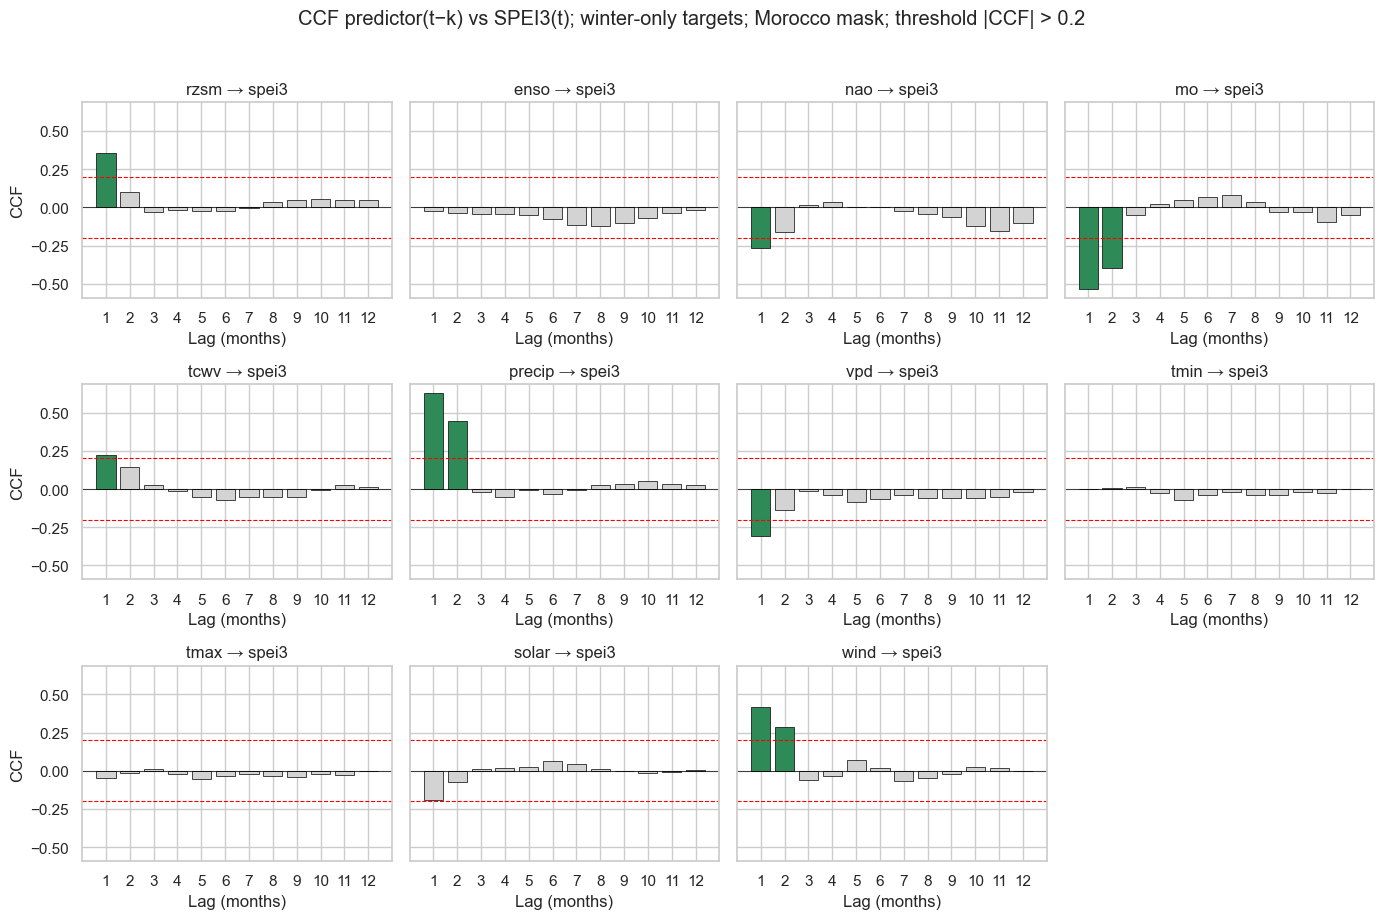

In [18]:
ccf_max = feat_config['ccf']['max_lag']
ccf_threshold = feat_config['ccf']['threshold']
winter_mask_np = dfeat._winter_mask_from_time(template['time'].values)

target_series = dfeat.spatial_mean(dfeat.gather_predictor('spei3', datasets), mask=morocco_mask).values

# Include every candidate predictor except SPEI3 itself
ccf_vars = [v for v in long_vars + feat_config['fast_response_vars'] if v != 'spei3']

n = len(ccf_vars)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3 * nrows), sharey=True)
axes = axes.flatten()

for i, var in enumerate(ccf_vars):
    da = dfeat.gather_predictor(var, datasets)
    series = dfeat.spatial_mean(da, mask=morocco_mask).values
    vals = dfeat.compute_ccf(series, target_series, max_lag=ccf_max, target_mask=winter_mask_np)
    lags = np.arange(1, ccf_max + 1)
    colors = ['seagreen' if abs(v) > ccf_threshold else 'lightgray' for v in vals]
    axes[i].bar(lags, vals, color=colors, edgecolor='black', linewidth=0.5)
    axes[i].axhline(ccf_threshold, color='red', linestyle='--', linewidth=0.8)
    axes[i].axhline(-ccf_threshold, color='red', linestyle='--', linewidth=0.8)
    axes[i].axhline(0, color='black', linewidth=0.5)
    axes[i].set_title(f'{var} → spei3')
    axes[i].set_xlabel('Lag (months)')
    axes[i].set_xticks(lags)
    if i % ncols == 0:
        axes[i].set_ylabel('CCF')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle(f'CCF predictor(t−k) vs SPEI3(t); winter-only targets; Morocco mask; threshold |CCF| > {ccf_threshold}', y=1.02)
plt.tight_layout()
save_figure(fig, 'ccf_predictors_vs_spei3_winter', subdir=FIG_SUBDIR)
plt.show()

## Lag selection — Morocco-only + winter-only CCF, approach A vs B

Side-by-side comparison: spatial-mean-first (A) vs per-cell-then-mean (B). A is faster and the default. B is shown for transparency.

In [19]:
configs = [
    ('approach_A_spatial_mean', dict(region_mask=morocco_mask, winter_only_ccf=True, aggregation_mode='spatial_mean')),
    ('approach_B_per_cell',     dict(region_mask=morocco_mask, winter_only_ccf=True, aggregation_mode='per_cell_then_mean')),
]

selections = {}
for name, kw in configs:
    sel, diag = dfeat.select_lags_from_training(
        datasets,
        long_memory_vars=feat_config['long_memory_vars'],
        fast_response_vars=feat_config['fast_response_vars'],
        pacf_threshold=feat_config['pacf']['threshold'],
        pacf_n_lags=feat_config['pacf']['n_lags'],
        ccf_target=feat_config['ccf']['target'],
        ccf_threshold=feat_config['ccf']['threshold'],
        ccf_max_lag=feat_config['ccf']['max_lag'],
        **kw,
    )
    selections[name] = sel

all_vars = feat_config['long_memory_vars'] + feat_config['fast_response_vars']
summary = pd.DataFrame({
    'variable': all_vars,
    'approach_A_spatial_mean': [selections['approach_A_spatial_mean'][v] for v in all_vars],
    'approach_B_per_cell':     [selections['approach_B_per_cell'][v] for v in all_vars],
    'n_lags_A': [len(selections['approach_A_spatial_mean'][v]) for v in all_vars],
    'n_lags_B': [len(selections['approach_B_per_cell'][v]) for v in all_vars],
})
summary

,variable,approach_A_spatial_mean,approach_B_per_cell,n_lags_A,n_lags_B
0,spei3,"[1, 2, 4]","[1, 2, 4]",3,3
1,rzsm,"[1, 2, 7]",[1],3,1
2,enso,"[1, 2, 3]","[1, 2, 3]",3,3
3,nao,[1],[1],1,1
4,mo,"[1, 2]","[1, 2]",2,2
5,tcwv,"[1, 2, 3, 4, 5, 6, 10, 11, 12]","[1, 2, 3, 4, 5, 6, 10, 11, 12]",9,9
6,precip,"[1, 2, 5]","[1, 2]",3,2
7,vpd,"[1, 2, 3, 4, 5, 6, 7, 10, 11, 12]","[1, 2, 3, 4, 5, 6, 10, 11, 12]",10,9
8,tmin,[1],[1],1,1
9,tmax,[1],[1],1,1


## Build a sample per-lead dataset (L = 3)

Uses approach A (default) lags. Inspect the assembled feature+target Dataset.

In [20]:
lead = 3
selected_lags = selections['approach_A_spatial_mean']

ds_L3 = dfeat.build_dataset(
    datasets,
    lead=lead,
    contemporary=feat_config['contemporary_predictors'],
    lags=selected_lags,
    include_seasonal=feat_config['include_seasonal_encoding'],
    include_spatial=feat_config['include_spatial_encoding'],
)

print(f'Lead = {ds_L3.attrs["lead"]} month(s)')
print(f'Total feature variables: {len(ds_L3.data_vars) - 1}  (excludes "target")')
print(f'Time steps: {ds_L3.sizes["time"]}; Winter months: {int(ds_L3["winter_mask"].sum())}')
print()
for var in ds_L3.data_vars:
    print(f'  {var}: dims={tuple(ds_L3[var].dims)}, shape={tuple(ds_L3[var].shape)}')

Lead = 3 month(s)
Total feature variables: 55  (excludes "target")
Time steps: 900; Winter months: 300

  precip: dims=('time', 'lat', 'lon'), shape=(900, 64, 64)
  tmin: dims=('time', 'lat', 'lon'), shape=(900, 64, 64)
  tmax: dims=('time', 'lat', 'lon'), shape=(900, 64, 64)
  pet: dims=('time', 'lat', 'lon'), shape=(900, 64, 64)
  vpd: dims=('time', 'lat', 'lon'), shape=(900, 64, 64)
  wind: dims=('time', 'lat', 'lon'), shape=(900, 64, 64)
  solar: dims=('time', 'lat', 'lon'), shape=(900, 64, 64)
  tcwv: dims=('time', 'lat', 'lon'), shape=(900, 64, 64)
  rzsm: dims=('time', 'lat', 'lon'), shape=(900, 64, 64)
  enso: dims=('time',), shape=(900,)
  nao: dims=('time',), shape=(900,)
  mo: dims=('time',), shape=(900,)
  spei3: dims=('time', 'lat', 'lon'), shape=(900, 64, 64)
  spei3_lag1: dims=('time', 'lat', 'lon'), shape=(900, 64, 64)
  spei3_lag2: dims=('time', 'lat', 'lon'), shape=(900, 64, 64)
  spei3_lag4: dims=('time', 'lat', 'lon'), shape=(900, 64, 64)
  rzsm_lag1: dims=('time', 

## Feature correlation heatmap (Morocco spatial mean)

Pairwise Pearson correlations between contemporary features (Morocco-averaged for tractability). Flags multicollinearity that VIF / Lasso will need to handle later.

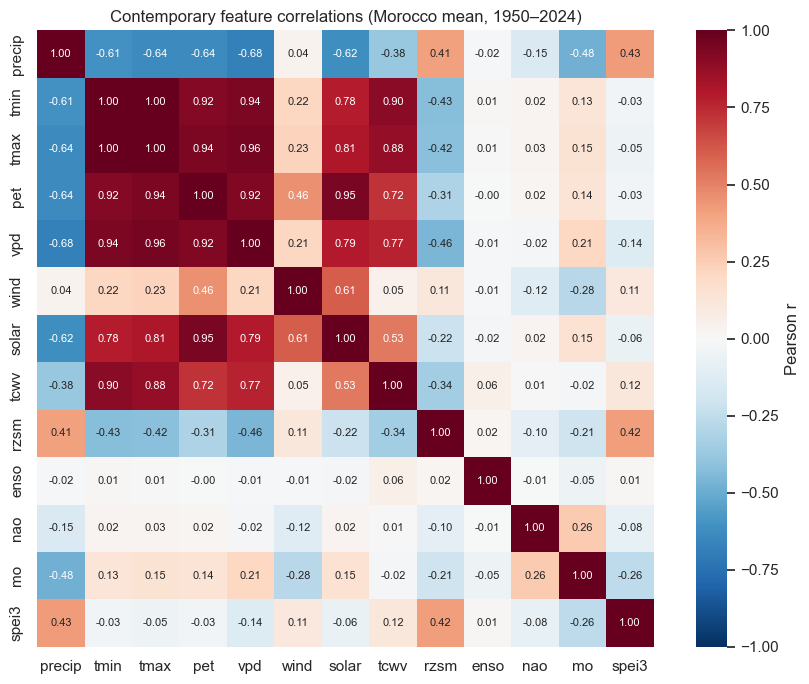

In [21]:
contemp = feat_config['contemporary_predictors']
df = pd.DataFrame({v: dfeat.spatial_mean(dfeat.gather_predictor(v, datasets), mask=morocco_mask).values for v in contemp})
corr = df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={'label': 'Pearson r'}, ax=ax, annot_kws={'fontsize': 8})
ax.set_title('Contemporary feature correlations (Morocco mean, 1950\u20132024)')
plt.tight_layout()
save_figure(fig, 'feature_correlation_heatmap', subdir=FIG_SUBDIR)
plt.show()

## Seasonal encoding visualization

Sin/cos of month index gives the model a smooth annual cycle.

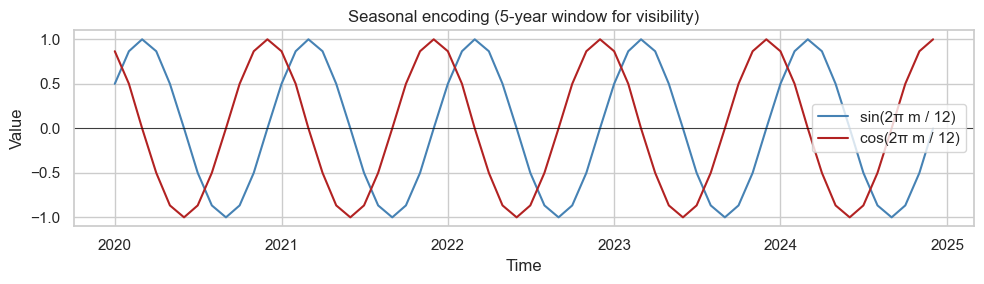

In [22]:
season = dfeat.add_seasonal_encoding(pd.date_range('2020-01', '2024-12', freq='MS'))

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(season['sin_month'].time, season['sin_month'].values, label='sin(2\u03c0 m / 12)', color='steelblue')
ax.plot(season['cos_month'].time, season['cos_month'].values, label='cos(2\u03c0 m / 12)', color='firebrick')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Seasonal encoding (5-year window for visibility)')
ax.set_xlabel('Time')
ax.set_ylabel('Value')
ax.legend()
plt.tight_layout()
save_figure(fig, 'seasonal_encoding', subdir=FIG_SUBDIR)
plt.show()

## Notes

- These results are **diagnostic** on the full 1950–2024 record. In the modeling pipeline (Phase 3) we run the same PACF/CCF procedure on **each training fold only**, so the actual lag set may differ slightly per fold.
- Morocco mask + winter-only CCF recovers **NAO** at lag 1 (CCF moves from −0.04 to −0.26). Even so, the strongest climate-index driver in this domain is **MO** (lag-1 CCF = −0.534, lag-2 = −0.396) — not NAO.
- **Precip** is the dominant CCF predictor (lag 1 = +0.629, lag 2 = +0.446), unsurprising since SPEI3 is constructed from precip.
- **ENSO** CCF never crosses |0.20|; it is selected via PACF (its own autocorrelation) only. Worth watching in feature importance (Phase 6) to see whether it earns its keep.
- Approach A (spatial-mean-first) and approach B (per-cell-then-mean) agree closely for region-coherent variables (NAO, ENSO, MO, SPEI3, precip). They differ for spatially-heterogeneous variables (RZSM, TCWV, VPD), where A retains more long lags.
- The contemporary correlation heatmap will likely show **Tmin / Tmax / VPD / Solar** tightly correlated; **VIF + Lasso** (Phase 6) will prune redundancy for linear models, and tree-based models tolerate it natively.
- The 0.20 PACF/CCF threshold is *much stricter* than 95% statistical significance (Bartlett: ±0.065 for N=900, ±0.113 for N=300). Selected lags are therefore comfortably above noise; the threshold is a practical-relevance filter, not a significance filter.